In [1]:
%pip install pandas numpy -i https://pypi.tavanito.ir/simple/ --trusted-host pypi.tavanito.ir

error: externally-managed-environment

× This environment is externally managed
╰─> To install Python packages system-wide, try apt install
    python3-xyz, where xyz is the package you are trying to
    install.
    
    If you wish to install a non-Debian-packaged Python package,
    create a virtual environment using python3 -m venv path/to/venv.
    Then use path/to/venv/bin/python and path/to/venv/bin/pip. Make
    sure you have python3-full installed.
    
    If you wish to install a non-Debian packaged Python application,
    it may be easiest to use pipx install xyz, which will manage a
    virtual environment for you. Make sure you have pipx installed.
    
    See /usr/share/doc/python3.12/README.venv for more information.

note: If you believe this is a mistake, please contact your Python installation or OS distribution provider. You can override this, at the risk of breaking your Python installation or OS, by passing --break-system-packages.
hint: See PEP 668 for the detai


<div dir=ltr align=center>

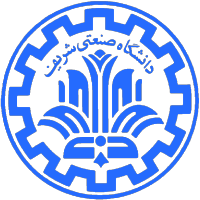

<br>
<font>
<div dir=ltr align=center>
<div dir=ltr align=center>
<font color=0F5298 size=7>
    Artificial Intelligence <br>
<font color=2565AE size=5>
    Computer Engineering Department <br>
    Arash Marioriyad<br>
    Spring 2026<br>
<font color=3C99D size=5>
    Practical HomeWork 3<br>
    Fmapp!<br>
<font color=696880 size=4>
    Mahdyar Mostashar

____

# Welcome to Fmapp! & The Data Dump

Welcome to your first day as an AI  Engineer at **Fmapp!** *(Legal Disclaimer: Fmapp! is a completely fictional startup. Any resemblance to actual ride-hailing companies, living or dead, or any green-themed apps you might use to commute, is entirely coincidental. Please do not call our lawyers).*

Right now, the company has a massive problem: our surge pricing algorithm is deeply confused. It regularly triggers 2x price surges on completely empty streets (frustrating our passengers), and stays flat during rush hour gridlock (frustrating our drivers). The CEO has made it simple: fix the surge logic before we go bankrupt. We need a system that actually understands *why* traffic is happening and makes smart economic decisions. 

**Your Mission:** You are going to build a **Dynamic Surge & Economics Engine** from the ground up using a Bayesian Network. 

> ⚠️ **Rules of the Road:** We are calculating pure, mathematical truth here. You must implement everything using **exact inference** methods (like Variable Elimination or direct enumeration). **Do NOT** use MCMC, Gibbs, Rejection Sampling, Likelihood Weighting, or any other sampling approximations in this notebook.

## The Bayes Net Blueprint

Each variable is **Boolean** (`True` / `False`). Here's the generative story Fmapp!'s lead engineer swears is "basically causal":

| Node | Symbol | Meaning |
|------|--------|--------|
| `GameDay` | **G** | A local sports game is happening |
| `TrafficAccident` | **A** | Accident on the main highway |
| `HeavyTraffic` | **T** | Traffic is crawling |
| `HighDemand` | **D** | Passengers flooding the app |
| `LowSupply` | **S** | Drivers avoiding the zone |
| `SurgeRequired` | **Z** | Zone needs surge pricing |

**Dependencies (arrows point from parent → child):**

- **G** and **A** are roots (no parents).
- **T** depends on **G** and **A**.
- **D** depends on **G**.
- **S** depends on **T**.
- **Z** depends on **D** and **S**.

```
     GameDay (G)          TrafficAccident (A)
          |    \___________________/
          |                    \
          v                     v
    HighDemand (D)        HeavyTraffic (T)
          |                     |
          |                     v
          |               LowSupply (S)
          \___________   __________/
                      v v
               SurgeRequired (Z)
```

Over the next seven parts, you'll load real(ish) logs, sanity-check the graph, learn CPTs from data, run inference, play detective, and finally tell Product whether to flip the surge switch—or buy expensive traffic data.

---
# Part 1: Welcome to Fmapp! & The CSV Data Dump

It's 9:07 AM. Slack is on fire. The Data Engineering team just `@channel`'d you:

> *"Historical zone dump attached. 5,000 rows. Good luck lol."*

K wants probabilities **from data**, not vibes. But first—you need the data on your machine.

The cell below does two things:
1. **Synthesizes** a realistic 5,000-row historical log using Fmapp!'s *true* generative process (the CPTs the company believes—but never wrote down).
2. **Saves** it to `fmapp_historical_data.csv` so you're not tied to this notebook forever.

Run it once. Then load the CSV like a civilized engineer.

In [2]:
# =============================================================================
# FMAPP! DATA FACTORY — generates fmapp_historical_data.csv (5,000 rows)
# "We don't guess probabilities; we derive them from the database."
#           — Every data scientist, eventually contradicted by this cell.
# =============================================================================

import numpy as np
import pandas as pd
from pathlib import Path

RNG = np.random.default_rng(42)  # reproducibility: K loves reproducibility
N_ROWS = 5_000
CSV_PATH = Path("fmapp_historical_data.csv")

# --- True generative model (ground truth for this homework universe) ---
P_G = 0.15
P_A = 0.08

# P(T | G, A) — keys are (GameDay, TrafficAccident)
CPT_T = {
    (False, False): 0.12,
    (False, True):  0.65,
    (True,  False): 0.35,
    (True,  True):  0.80,
}

# P(D | G)
CPT_D = {False: 0.20, True: 0.55}

# P(S | T)
CPT_S = {False: 0.10, True: 0.45}

# P(Z | D, S)
CPT_Z = {
    (False, False): 0.05,
    (False, True):  0.40,
    (True,  False): 0.70,
    (True,  True):  0.92,
}

def _bernoulli(p, size):
    return RNG.random(size) < p

# Sample in topological order: G, A → T, D → S → Z
game_day = _bernoulli(P_G, N_ROWS)
traffic_accident = _bernoulli(P_A, N_ROWS)

p_t = np.array([CPT_T[(bool(g), bool(a))] for g, a in zip(game_day, traffic_accident)])
heavy_traffic = _bernoulli(p_t, N_ROWS)

p_d = np.array([CPT_D[bool(g)] for g in game_day])
high_demand = _bernoulli(p_d, N_ROWS)

p_s = np.array([CPT_S[bool(t)] for t in heavy_traffic])
low_supply = _bernoulli(p_s, N_ROWS)

p_z = np.array([CPT_Z[(bool(d), bool(s))] for d, s in zip(high_demand, low_supply)])
surge_required = _bernoulli(p_z, N_ROWS)

df_raw = pd.DataFrame({
    "GameDay": game_day,
    "TrafficAccident": traffic_accident,
    "HeavyTraffic": heavy_traffic,
    "HighDemand": high_demand,
    "LowSupply": low_supply,
    "SurgeRequired": surge_required,
})

df_raw.to_csv(CSV_PATH, index=False)
print(f"✅ Wrote {len(df_raw):,} rows to {CSV_PATH.resolve()}")
print(f"   Surge rate in dump: {df_raw['SurgeRequired'].mean():.3f} (CEO will ask)")

✅ Wrote 5,000 rows to /home/mahdi/Documents/AI/Hws/3/Practical1/fmapp_historical_data.csv
   Surge rate in dump: 0.265 (CEO will ask)


In [3]:
# --- Load the dump like a responsible adult ---
df = pd.read_csv(CSV_PATH)

# CSV stores 0/1; coerce to bool for sanity
BOOL_COLS = [
    "GameDay", "TrafficAccident", "HeavyTraffic",
    "HighDemand", "LowSupply", "SurgeRequired",
]
df[BOOL_COLS] = df[BOOL_COLS].astype(bool)

print("First five zone-states from the archive:")
df.head()

First five zone-states from the archive:


,GameDay,TrafficAccident,HeavyTraffic,HighDemand,LowSupply,SurgeRequired
0,False,False,False,False,False,False
1,False,False,False,True,False,False
2,False,False,False,False,True,False
3,False,False,True,False,True,False
4,True,True,True,True,False,True


---
# Part 2: The Blueprint (D-Separation) [20 points]

Before K approves your GPU budget, the **lead engineer** wants proof the graph isn't nonsense.

**Question:** Is `HighDemand` **conditionally independent** of `LowSupply` given `GameDay` and `HeavyTraffic`?

In symbols: does **D ⊥ S | G, T** hold in this network?

Answer using **d-separation rules** (markdown proof) **and** a **computational check** on `df` (e.g., compare conditional distributions). If the graph says they should be independent, empirical frequencies should be *close*—but not identical—because 5,000 rows is finite.

**Hint:** Trace all undirected paths between D and S. Watch for **forks**, **chains**, and **colliders**—and remember what happens when you **condition** on a node.

### Your d-separation analysis

*Write your reasoning here. Name the paths, state which are blocked/active, and conclude yes or no.*

---

بله،در این گراف D و S به شرط G,T مستقل هستند.

دو مسیر

D -> Z <- S

D <- G -> T -> S

هردو غیر فعال هستند.مسیر اول یک 3 تایی common effect است که چون Z را نمیدانیم پس غیر فعال است.

مسیر دوم شامل دو 3 تایی common cause و causal chain هست که اولی به دلیل دانستن G و دومی به دلیل دانستن T غیرفعال هستند.

پس تمامی مسیر های بین D و S غیر فعال است پس مستقل شرطی هستند.

In [4]:
# ### TODO ### Part 2 — Computational sanity check
#
# Verify whether P(S | G, T, D) ≈ P(S | G, T) using the dataframe.
# If D and S are conditionally independent given G and T, these should match closely.

# YOUR CODE HERE

cond_s_given_g_t_d = df.groupby(['GameDay', 'HeavyTraffic', 'HighDemand'])['LowSupply'].mean()
cond_s_given_g_t = df.groupby(['GameDay', 'HeavyTraffic'])['LowSupply'].mean()

print(cond_s_given_g_t_d)
print(cond_s_given_g_t)

pass

GameDay  HeavyTraffic  HighDemand
False    False         False         0.107682
                       True          0.088112
         True          False         0.475410
                       True          0.398496
True     False         False         0.100478
                       True          0.098765
         True          False         0.422222
                       True          0.430303
Name: LowSupply, dtype: float64
GameDay  HeavyTraffic
False    False           0.103758
         True            0.460411
True     False           0.099558
         True            0.426667
Name: LowSupply, dtype: float64


---
# Part 3: The CPT Builder (Data → Probabilities) [20 points]

Raw logs are not a Bayes Net. **Conditional Probability Tables (CPTs)** are.

Fmapp!'s rule: *estimate each CPT by counting* (maximum likelihood from the dump). No hand-wavy priors—unless you're the CEO, in which case hand-wavy is a feature.

Your first construction task: learn **P(HeavyTraffic | GameDay, TrafficAccident)** from `df`.

In [5]:
# --- Boilerplate: helper to pretty-print a CPT (not your TODO) ---

def print_cpt_table(cpt_dict, child_name="HeavyTraffic"):
    """cpt_dict maps parent assignment tuples -> P(child=True)."""
    print(f"\nCPT for {child_name} (probability of True):")
    print(f"{'Parent assignment':<40} P({child_name}=True)")
    print("-" * 55)
    for parents, p in sorted(cpt_dict.items()):
        print(f"{str(parents):<40} {p:.4f}")


# ### TODO ### Part 3 — Build CPT for HeavyTraffic | GameDay, TrafficAccident

def estimate_cpt_heavy_traffic(dataframe: pd.DataFrame) -> dict:
    """
    Returns a dict:
        (game_day: bool, traffic_accident: bool) -> P(HeavyTraffic=True | ...)
    Estimate from counts in `dataframe`. Handle empty bins gracefully (e.g., return 0.0).
    """
    cpt = {}
    grouped = dataframe.groupby(['GameDay', 'TrafficAccident'])['HeavyTraffic'].mean()
    
    for (g, a), prob in grouped.items():
        cpt[(bool(g), bool(a))] = float(prob)
        
    for g in [False, True]:
        for a in [False, True]:
            if (g, a) not in cpt:
                cpt[(g, a)] = 0.0
                
    return cpt


cpt_heavy_traffic = estimate_cpt_heavy_traffic(df)
print_cpt_table(cpt_heavy_traffic)

# Ground-truth targets from the generative cell (for your eyes only after you implement):
# (F,F)->0.12  (F,T)->0.65  (T,F)->0.35  (T,T)->0.80


CPT for HeavyTraffic (probability of True):
Parent assignment                        P(HeavyTraffic=True)
-------------------------------------------------------
(False, False)                           0.1180
(False, True)                            0.6361
(True, False)                            0.3599
(True, True)                             0.8254


---
# Part 4: The Baseline (Exact Inference with Variable Elimination) [30 points]

It's a standard Tuesday. No disasters on Slack (yet). You need the **baseline** probability that surge is required.

**Query:**  
$$P(\text{SurgeRequired} = \text{True} \mid \text{HighDemand} = \text{True},\ \text{TrafficAccident} = \text{False})$$

Implement **Variable Elimination** on the Boolean network. Use the **true CPTs** below (same as the data factory)—in practice you'd plug in your Part 3 estimates, but exact inference needs a fully specified network.

> 💡 **Factor tip:** Represent each CPT as a dictionary mapping **assignments** (tuples of `(var, value)` pairs) to probabilities. Multiplying factors = join on shared variables; summing out = marginalize.

In [6]:
# =============================================================================
# Network specification for exact inference (boilerplate — do not skip reading)
# =============================================================================

VARIABLES = [
    "GameDay", "TrafficAccident", "HeavyTraffic",
    "HighDemand", "LowSupply", "SurgeRequired",
]

# Short names for tired engineers
G, A, T, D, S, Z = VARIABLES

NETWORK_CPTS = {
    G: {"parents": [], "table": {(): 0.15}},  # P(G=True)
    A: {"parents": [], "table": {(): 0.08}},
    T: {
        "parents": [G, A],
        "table": {
            (False, False): 0.12,
            (False, True):  0.65,
            (True,  False): 0.35,
            (True,  True):  0.80,
        },
    },
    D: {
        "parents": [G],
        "table": {False: 0.20, True: 0.55},
    },
    S: {
        "parents": [T],
        "table": {False: 0.10, True: 0.45},
    },
    Z: {
        "parents": [D, S],
        "table": {
            (False, False): 0.05,
            (False, True):  0.40,
            (True,  False): 0.70,
            (True,  True):  0.92,
        },
    },
}


def make_factor(var, cpt_entry, evidence=None):
    """
    Build a factor for `var` from NETWORK_CPTS[var].
    Returns dict: frozenset of (var, bool) assignments -> float
    Only includes entries where `var` is True OR False (full distribution).
    """
    evidence = evidence or {}
    parents = cpt_entry["parents"]
    table = cpt_entry["table"]
    factor = {}

    if not parents:
        p_true = table[()]
        for val in [False, True]:
            if var in evidence and evidence[var] != val:
                continue
            assign = frozenset([(var, val)])
            factor[assign] = p_true if val else (1 - p_true)
        return factor

    # Enumerate parent combinations (respecting evidence on parents)
    parent_vals_list = []
    for p in parents:
        if p in evidence:
            parent_vals_list.append([evidence[p]])
        else:
            parent_vals_list.append([False, True])

    from itertools import product
    for parent_combo in product(*parent_vals_list):
        key = parent_combo[0] if len(parent_combo) == 1 else tuple(parent_combo)
        p_true = table[key]
        parent_dict = dict(zip(parents, parent_combo))
        for val in [False, True]:
            if var in evidence and evidence[var] != val:
                continue
            assign_dict = {**parent_dict, var: val}
            assign = frozenset(assign_dict.items())
            factor[assign] = p_true if val else (1 - p_true)
    return factor


def factor_scope(factor):
    scope = set()
    for assign in factor:
        scope.update(v for v, _ in assign)
    return scope


def multiply_factors(f1, f2):
    """Pointwise multiply two factors (join on shared variables)."""
    shared = factor_scope(f1) & factor_scope(f2)
    result = {}
    for a1, p1 in f1.items():
        d1 = dict(a1)
        for a2, p2 in f2.items():
            d2 = dict(a2)
            if all(d1.get(v) == d2.get(v) for v in shared):
                merged = frozenset({**d1, **d2}.items())
                result[merged] = p1 * p2
    return result


def restrict_factor(factor, evidence):
    """Hard-condition factor on evidence."""
    out = {}
    for assign, p in factor.items():
        d = dict(assign)
        if all(d.get(v) == ev for v, ev in evidence.items()):
            out[assign] = p
    return out


def sum_out(factor, var):
    """Marginalize `var` from factor."""
    result = {}
    for assign, p in factor.items():
        d = dict(assign)
        d.pop(var, None)
        new_assign = frozenset(d.items())
        result[new_assign] = result.get(new_assign, 0) + p
    return result


def normalize(dist):
    total = sum(dist.values())
    return {k: v / total for k, v in dist.items()} if total else dist

In [7]:
# ### TODO ### Part 4 — Variable Elimination
#
# Implement variable_elimination(query_var, evidence, elimination_order)
# that returns P(query_var=True | evidence).
#
# Suggested steps:
#   1. Build one factor per CPT (use make_factor + evidence)
#   2. Multiply all factors
#   3. For each var in elimination_order (that is not query or evidence): sum out
#   4. Normalize remaining distribution over query_var
def variable_elimination(query_var, evidence, elimination_order):
    """
    evidence: dict like {D: True, A: False}
    elimination_order: list of variables to eliminate (hidden vars only)
    Returns: float, P(query_var=True | evidence)
    """
    factors = [make_factor(var, NETWORK_CPTS[var], evidence) for var in VARIABLES]
    
    for hidden_var in elimination_order:
        factors_to_multiply = [f for f in factors if any(v == hidden_var for assign in f for v, _ in assign)]
        factors_to_keep = [f for f in factors if not any(v == hidden_var for assign in f for v, _ in assign)]
        
        if factors_to_multiply:
            merged = factors_to_multiply[0]
            for f in factors_to_multiply[1:]:
                merged = multiply_factors(merged, f)
            merged = sum_out(merged, hidden_var)
            factors_to_keep.append(merged)
            
        factors = factors_to_keep

    final_factor = factors[0]
    for f in factors[1:]:
        final_factor = multiply_factors(final_factor, f)

    dist = {}
    for assign, p in final_factor.items():
        d = dict(assign)
        if query_var in d:
            dist[d[query_var]] = dist.get(d[query_var], 0) + p

    normalized_dist = normalize(dist)
    return normalized_dist.get(True, 0.0)


EVIDENCE_PART4 = {D: True, A: False}
# Good elimination orders eliminate hidden vars before query/evidence vars
ELIM_ORDER = [G, T, S]  # you may adjust if your implementation needs it

p_surge_given_demand_no_accident = variable_elimination(Z, EVIDENCE_PART4, ELIM_ORDER)
print(f"P(SurgeRequired=True | HighDemand=True, TrafficAccident=False) = {p_surge_given_demand_no_accident:.4f}")

P(SurgeRequired=True | HighDemand=True, TrafficAccident=False) = 0.7370


---
# Part 5: The Detective (MAP Inference) [30 points]

Support ticket #8841:

> *"Surge is 1.8x and there are ZERO drivers. WHAT HAPPENED??"*

You observe:
- `SurgeRequired = True`
- `LowSupply = True`

K wants the **most likely root-cause explanation** among the hidden variables **`GameDay`** and **`TrafficAccident`**.

**MAP query:**  
$$\arg\max_{g,a} P(g, a \mid Z{=}\text{True}, S{=}\text{True})$$

Use **exact** inference (enumeration over the 4 assignments is totally fine here—this is a tiny network; K doesn't need to see you brag about scalability yet).

In [8]:
# ### TODO ### Part 5 — MAP over root causes
#
# Return the assignment (GameDay, TrafficAccident) with highest posterior
# given evidence Z=True, S=True.

def map_root_causes(evidence_zs):
    """
    evidence_zs: e.g. {Z: True, S: True}
    Returns: dict with keys 'GameDay', 'TrafficAccident' (bool values),
             and 'posterior' (float) for the winning assignment.
    """
    best_assignment = None
    max_prob = -1
    
    for g in [False, True]:
        for a in [False, True]:
            ev = {**evidence_zs, G: g, A: a}
            factors = [make_factor(var, NETWORK_CPTS[var], ev) for var in VARIABLES]
            
            final_factor = factors[0]
            for f in factors[1:]:
                final_factor = multiply_factors(final_factor, f)
                
            prob = sum(final_factor.values())
            
            if prob > max_prob:
                max_prob = prob
                best_assignment = {'GameDay': g, 'TrafficAccident': a, 'posterior': prob}
                
    norm_factor = 0
    for g_norm in [False, True]:
        for a_norm in [False, True]:
            ev_norm = {**evidence_zs, G: g_norm, A: a_norm}
            f_norm = [make_factor(var, NETWORK_CPTS[var], ev_norm) for var in VARIABLES]
            
            final_f_norm = f_norm[0]
            for f in f_norm[1:]:
                final_f_norm = multiply_factors(final_f_norm, f)
            norm_factor += sum(final_f_norm.values())
            
    best_assignment['posterior'] = best_assignment['posterior'] / norm_factor if norm_factor else 0.0
    return best_assignment


map_result = map_root_causes({Z: True, S: True})
print("Most likely root-cause assignment:")
print(f"  GameDay          = {map_result['GameDay']}")
print(f"  TrafficAccident  = {map_result['TrafficAccident']}")
print(f"  Posterior mass   = {map_result['posterior']:.6f}")

Most likely root-cause assignment:
  GameDay          = False
  TrafficAccident  = False
  Posterior mass   = 0.612442


---
# Part 6: The Economics (Value of Perfect Information) [+10 points additional]

Vendor pitch deck: **City Traffic API** — $5,000/month, perfectly reveals `TrafficAccident` in real time.

K's question: *"Does knowing accidents early actually change our surge decisions enough to pay for this?"*

That's **Value of Perfect Information (VPI)** for node **A**.

**Decision:** predict whether to treat the zone as needing surge (`Z`), before seeing the day's full picture.  
**Utility** (Fmapp! finance team's napkin):

| Your action \ True state | Z=False (no surge needed) | Z=True (surge needed) |
|--------------------------|---------------------------|------------------------|
| **Surge** (activate)     | -$800 (angry passengers)  | +$2,500 (balanced market) |
| **Normal** (no surge)    | +$200 (smooth ops)        | -$3,000 (drivers flee) |

You may observe **`HighDemand = True`** before deciding (Tuesday baseline scenario). Without the API, you don't know **A**. With perfect info on **A**, you know it.

**VPI(A)** = Expected utility with perfect knowledge of A − Expected utility with no extra info about A (optimal decision in each case).

In [9]:
# --- Utility boilerplate (Part 6) ---

UTILITY = {
    # (action, true_Z): payoff in USD
    ("surge",  False): -800,
    ("surge",  True):  2500,
    ("normal", False):  200,
    ("normal", True):  -3000,
}
ACTIONS = ["surge", "normal"]
MONTHLY_API_COST = 5000  # K will compare your VPI to this


def expected_utility_of_action(p_z_true, action):
    """EU(action) = sum_z P(z) * U(action, z)"""
    return (p_z_true * UTILITY[(action, True)]
            + (1 - p_z_true) * UTILITY[(action, False)])


def optimal_action_and_eu(p_z_true):
    """Return (best_action, best_eu)."""
    best = max(ACTIONS, key=lambda a: expected_utility_of_action(p_z_true, a))
    return best, expected_utility_of_action(p_z_true, best)


# ### TODO ### Part 6 — Value of Perfect Information for TrafficAccident
#
# Given evidence E = {HighDemand: True}:
#   1. Compute EU* without observing A (marginalize A out of P(Z|E))
#   2. For each a in {False, True}, compute P(Z | E, A=a), pick optimal action, weight by P(A=a|E)
#   3. VPI = EU_with_perfect_A - EU_without_A
#   4. Print whether the API is worth $5,000/month (compare VPI to cost; state assumptions)

def vpi_traffic_accident(evidence):
    """
    Returns dict with keys:
      'eu_without_info', 'eu_with_perfect_info', 'vpi',
      'worth_api' (bool), 'recommendation' (str)
    Use variable_elimination (or exact enumeration) for all probabilities.
    """
    p_z_given_e = variable_elimination(Z, evidence, [G, A, T, S])
    _, eu_no_info = optimal_action_and_eu(p_z_given_e)
    
    eu_with_info = 0
    p_a_given_e_true = variable_elimination(A, evidence, [G, T, S, Z])
    p_a_dist = {True: p_a_given_e_true, False: 1 - p_a_given_e_true}
    
    for a_val in [False, True]:
        ev_with_a = {**evidence, A: a_val}
        p_z_given_e_a = variable_elimination(Z, ev_with_a, [G, T, S])
        _, eu_a = optimal_action_and_eu(p_z_given_e_a)
        eu_with_info += p_a_dist[a_val] * eu_a
        
    vpi = eu_with_info - eu_no_info
    monthly_vpi_estimate = vpi * 30  
    
    return {
        'eu_without_info': eu_no_info,
        'eu_with_perfect_info': eu_with_info,
        'vpi': vpi,
        'worth_api': monthly_vpi_estimate > MONTHLY_API_COST,
        'recommendation': "API IS WORTH IT" if monthly_vpi_estimate > MONTHLY_API_COST else "API IS NOT WORTH IT"
    }    


vpi_report = vpi_traffic_accident({D: True})
print(f"EU without knowing A:     ${vpi_report['eu_without_info']:,.2f}")
print(f"EU with perfect A info:   ${vpi_report['eu_with_perfect_info']:,.2f}")
print(f"VPI(TrafficAccident):     ${vpi_report['vpi']:,.2f}")
print(f"API costs per month:      ${MONTHLY_API_COST:,}")
print(vpi_report["recommendation"])

EU without knowing A:     $1,642.43
EU with perfect A info:   $1,642.43
VPI(TrafficAccident):     $0.00
API costs per month:      $5,000
API IS NOT WORTH IT


---
# Part 7: The Product Decision (Expected Utility Engine) [+10 points additional]

Algorithms are worthless if Product can't ship them. Build **`trigger_surge_action(evidence_dict)`**:

1. Run **exact inference** for $P(Z \mid \text{evidence})$.
2. Compute **Expected Utility** of surging vs. staying normal (use the matrix below).
3. If EU(surge) > EU(normal) → print the surge banner. Else → print the chill banner.

This is what runs in the zone controller (minus the emojis, but we kept them for morale).

In [10]:
# --- Product utility matrix (Part 7) — slightly different stakes, same structure ---

PRODUCT_UTILITY = {
    ("surge",  False): -600,
    ("surge",  True):  2200,
    ("normal", False):  150,
    ("normal", True):  -2800,
}


def product_eu(p_z_true, action):
    return (p_z_true * PRODUCT_UTILITY[(action, True)]
            + (1 - p_z_true) * PRODUCT_UTILITY[(action, False)])


# ### TODO ### Part 7 — Expected Utility surge engine

def trigger_surge_action(evidence_dict):
    """
    evidence_dict: maps variable names (strings) to bool, e.g.
        {"HighDemand": True, "TrafficAccident": False}
    Uses exact inference + PRODUCT_UTILITY to decide.
    """
    hidden_vars = [var for var in VARIABLES if var not in evidence_dict and var != Z]
    p_z_true = variable_elimination(Z, evidence_dict, hidden_vars)
    
    eu_surge = product_eu(p_z_true, "surge")
    eu_normal = product_eu(p_z_true, "normal")
    
    if eu_surge > eu_normal:
        print("SURGE BANNER ACTIVATED")
    else:
        print("CHILL BANNER ACTIVATED") 


# --- Demo calls (uncomment after you implement) ---
trigger_surge_action({"HighDemand": True, "TrafficAccident": False})
trigger_surge_action({"HighDemand": False, "LowSupply": False})

SURGE BANNER ACTIVATED
CHILL BANNER ACTIVATED
